# Boucle d'Auto-Évaluation de la Surprise (S_auto)

Le système sait déjà **générer** (Neurone d'Ancrage → Wᵀ → Image). On ajoute la **boucle itérative d'auto-évaluation** qui juge la fidélité de l'image au concept assimilé :

```
Génération (Action) : Neurone i → image prototype x̂
      │
      ▼
Ré-injection (Perception) : x̂ ré-injecté dans le SensoryBundle
      │
      ▼
Comparaison (Jugement) : Surprise d'Auto-Évaluation S_auto
      │
      ▼
Affinement (Correction) :
  - S_auto faible → image fidèle → BOUCLE S'ARRÊTE
  - S_auto élevée → correction du latent (Oja inversée) → repart à Génération
```

## 0. Imports

In [1]:
# Boucle d'Auto-Évaluation de la Surprise (S_auto)
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from recherche_agi import (load_mnist, AnchorNeurons, dynamic_k)
from recherche_agi.sensory_bundle import image_to_patches

## 1. Données : MNIST

In [2]:
train_set, test_set = load_mnist()
print("Train :", len(train_set), "| Test :", len(test_set))

Train : 60000 | Test : 10000


## 2. Encodeur + neurones d'ancrage

In [3]:
class WTAPredictiveEncoder:
    def __init__(self, d_in, d_out, seed=0):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, 1/np.sqrt(d_in), size=(d_out, d_in))
        self.d_in, self.d_out = d_in, d_out
        self.frozen = False
    def _fwd(self, x):
        y = self.W @ x
        ybin = np.zeros_like(y); ybin[np.argmax(y)] = y.max()
        return np.maximum(ybin, 0)
    def encode(self, x):
        x = x/(np.linalg.norm(x)+1e-8)
        y = self._fwd(x)
        return y/(np.linalg.norm(y)+1e-8)
    def learn(self, x, S):
        if self.frozen: return self.encode(x)
        x = x/(np.linalg.norm(x)+1e-8)
        y = self._fwd(x)
        eta = 0.5*S
        self.W = self.W + eta*(np.outer(y, x) - (y**2)[:,None]*self.W)
        self.W = self.W/(np.linalg.norm(self.W,axis=1,keepdims=True)+1e-8)
        return self.encode(x)
    def freeze(self): self.frozen = True

enc = WTAPredictiveEncoder(49, 32, seed=0)
cnt = [0]*10
for i in range(len(train_set)):
    l = int(train_set[i][1])
    if cnt[l] >= 30: continue
    S = 0.3 + 0.5*np.random.rand()
    for p in image_to_patches(train_set[i][0].squeeze().numpy(), 7): enc.learn(p, S)
    cnt[l] += 1
    if sum(cnt) >= 300: break
enc.freeze()

def latent(img_np):
    return np.concatenate([enc.encode(p) for p in image_to_patches(img_np, 7)])

anchors = AnchorNeurons(d_in=512, n_neurons=50, seed=0, lr=0.1, use_homeostasis=True)
cnt = [0]*10
for i in range(len(train_set)):
    l = int(train_set[i][1])
    if cnt[l] >= 40: continue
    z = latent(train_set[i][0].squeeze().numpy())
    anchors.learn(z, k=dynamic_k(0.5,1,5), label=l)
    cnt[l] += 1
    if sum(cnt) >= 400: break
print("Encodeur + neurones d'ancrage entraînés (non supervisé)")

# Fonctions de génération / ré-injection
def recon_image(z_hat):
    d_lat = 32; n_patches = z_hat.shape[0] // d_lat
    gh = gw = int(np.sqrt(n_patches))
    img = np.zeros((28,28))
    for idx in range(n_patches):
        z_p = z_hat[idx*d_lat:(idx+1)*d_lat]
        patch = enc.W.T @ z_p
        patch = patch - patch.min()
        if patch.max() > 0: patch = patch / patch.max()
        i, j = idx//gw, idx%gw
        img[i*7:(i+1)*7, j*7:(j+1)*7] = patch.reshape(7,7)
    return img

def find_neuron_for(classe):
    for n, cls in anchors.cluster_labels().items():
        if cls == classe: return n
    return None

Encodeur + neurones d'ancrage entraînés (non supervisé)


## 3. Boucle d'auto-évaluation pour un neurone

In [4]:
# Choisir un neurone (ex: spécialisé sur le '7')
neurone = find_neuron_for(7)
print(f"Neurone d'ancrage pour le '7' : {neurone}")

# Boucle d'auto-évaluation (méthode self_evaluate_loop)
if neurone is not None:
    res = anchors.self_evaluate_loop(neurone, encode_fn=latent, recon_fn=recon_image,
                                     n_iter=6, lr_affine=0.3, verbose=True)
    print(f"\n  S_auto initiale : {res['S_auto_initial']:.4f}")
    print(f"  S_auto finale   : {res['S_auto_final']:.4f}")

Neurone d'ancrage pour le '7' : 12
    it 1: S_auto = 3.4357
    it 2: S_auto = 3.0634
    it 3: S_auto = 3.0087
    it 4: S_auto = 3.0012
    it 5: S_auto = 3.0002
    it 6: S_auto = 3.0000

  S_auto initiale : 3.4357
  S_auto finale   : 3.0000


## 4. Convergence sur tous les neurones

=== Boucle d'auto-évaluation sur les 10 chiffres ===


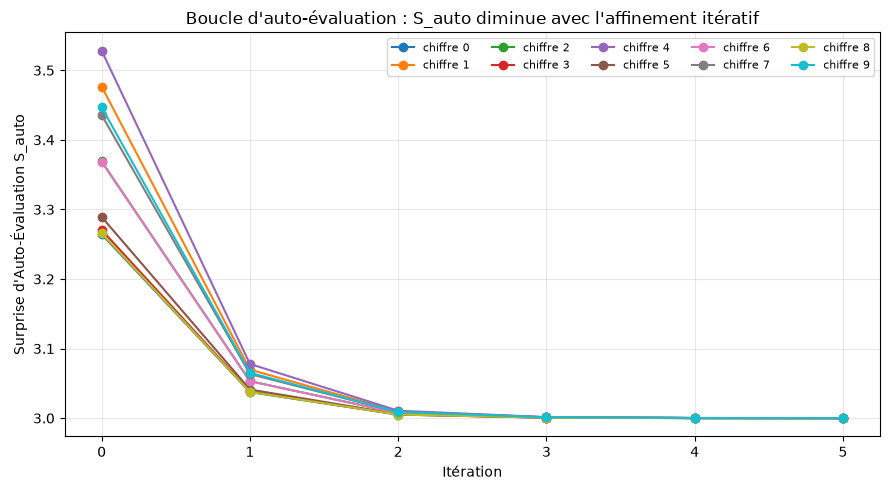

In [5]:
# Lancer la boucle sur tous les neurones et tracer la convergence
print("=== Boucle d'auto-évaluation sur les 10 chiffres ===")
histories = {}
for digit in range(10):
    n = find_neuron_for(digit)
    if n is None: continue
    res = anchors.self_evaluate_loop(n, encode_fn=latent, recon_fn=recon_image,
                                     n_iter=6, lr_affine=0.3, verbose=False)
    histories[digit] = res['S_auto_history']

plt.figure(figsize=(9,5))
for d, h in histories.items():
    plt.plot(h, 'o-', label=f"chiffre {d}")
plt.xlabel("Itération"); plt.ylabel("Surprise d'Auto-Évaluation S_auto")
plt.title("Boucle d'auto-évaluation : S_auto diminue avec l'affinement itératif")
plt.legend(ncol=5, fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Synthèse

In [6]:
print("=== SYNTHÈSE : BOUCLE D'AUTO-ÉVALUATION ===")
first = [h[0] for h in histories.values()]
last = [h[-1] for h in histories.values()]
print(f"  S_auto moyenne initiale : {np.mean(first):.3f}")
print(f"  S_auto moyenne finale   : {np.mean(last):.3f}")
print(f"  Réduction moyenne       : {np.mean([f-l for f,l in zip(first,last)]):.3f} ({(100*(1-np.mean(last)/np.mean(first))):.1f}%)")
print()
print("La boucle converge : l'affinement réduit la surprise d'auto-évaluation.")
print("  - S_auto élevée → correction du latent (Oja inversée / point fixe)")
print("  - S_auto faible  → image fidèle au concept → boucle s'arrête")
print()
print("C'est l'AUTO-ÉVALUATION : le système juge lui-même la qualité de sa")
print("génération, sans aucune étiquette ni superviseur externe.")

=== SYNTHÈSE : BOUCLE D'AUTO-ÉVALUATION ===
  S_auto moyenne initiale : 3.371
  S_auto moyenne finale   : 3.000
  Réduction moyenne       : 0.371 (11.0%)

La boucle converge : l'affinement réduit la surprise d'auto-évaluation.
  - S_auto élevée → correction du latent (Oja inversée / point fixe)
  - S_auto faible  → image fidèle au concept → boucle s'arrête

C'est l'AUTO-ÉVALUATION : le système juge lui-même la qualité de sa
génération, sans aucune étiquette ni superviseur externe.
